# AnalyticGAN -- Notebook 6: Classifier - Demo - Final Report

- **Part 1:** Fraud detection classifier (Real / Synthetic / Mixed)
- **Part 2:** Streamlit demo app (written to `app/streamlit_app.py`)
- **Part 3:** Final project report with all evaluation figures


In [39]:
import os, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             roc_curve)
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import LabelEncoder

import kagglehub

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [40]:
_here    = os.path.abspath(os.getcwd())
BASE     = _here if os.path.basename(_here) != "notebooks" else os.path.dirname(_here)
CKPT_DIR = os.path.join(BASE, "checkpoints")
APP_DIR  = os.path.join(BASE, "app")
os.makedirs(APP_DIR, exist_ok=True)

_kaggle_root = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
from pathlib import Path as _Path
_cands = list(_Path(_kaggle_root).rglob("creditcard.csv"))
if not _cands:
    raise FileNotFoundError("creditcard.csv not found under kagglehub path")
RAW_CSV = str(_cands[0])

print(f"BASE     : {BASE}")
print(f"CKPT_DIR : {CKPT_DIR}")
print(f"APP_DIR  : {APP_DIR}")


BASE     : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan
CKPT_DIR : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints
APP_DIR  : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\app


## Class Definitions (same as Notebook 05)


In [41]:
class VGMEncoder:
    def __init__(self, n_components=10, eps=0.005):
        self.n_components = n_components
        self.eps          = eps
        self.bgm = BayesianGaussianMixture(
            n_components=n_components,
            weight_concentration_prior_type="dirichlet_process",
            weight_concentration_prior=0.001,
            max_iter=100, random_state=42, n_init=1)
        self.valid_components = None
        self.n_valid          = None

    def fit(self, data):
        data = np.asarray(data).reshape(-1, 1)
        self.bgm.fit(data)
        self.valid_components = np.where(self.bgm.weights_ > self.eps)[0]
        self.n_valid = len(self.valid_components)
        return self

    def transform(self, data):
        data  = np.asarray(data).reshape(-1, 1)
        means = self.bgm.means_[self.valid_components].flatten()
        stds  = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()
        probs = self.bgm.predict_proba(data)[:, self.valid_components]
        mode_idx = []
        for p in probs:
            s      = p.sum()
            p_norm = (p / s).astype(np.float64) if (s > 0 and np.isfinite(s)) else np.ones(self.n_valid) / self.n_valid
            mode_idx.append(np.random.choice(self.n_valid, p=p_norm))
        mode_idx   = np.array(mode_idx)
        normalized = np.clip(
            (data.flatten() - means[mode_idx]) / (4 * stds[mode_idx] + 1e-8),
            -0.99, 0.99)
        one_hot = np.zeros((len(data), self.n_valid), dtype=np.float32)
        one_hot[np.arange(len(data)), mode_idx] = 1
        return np.column_stack([normalized, one_hot]).astype(np.float32)

    def inverse_transform(self, encoded):
        encoded  = np.asarray(encoded)
        means    = self.bgm.means_[self.valid_components].flatten()
        stds     = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()
        mode_idx = np.argmax(encoded[:, 1:], axis=1)
        return encoded[:, 0] * 4 * stds[mode_idx] + means[mode_idx]


class TabularPreprocessor:
    def __init__(self, max_gmm_components=10, eps=0.005):
        self.max_gmm_components = max_gmm_components
        self.eps             = eps
        self.continuous_cols = []
        self.categorical_cols= []
        self.target_col      = None
        self.vgm_encoders    = {}
        self.label_encoders  = {}
        self.cat_dims        = {}
        self.output_info     = []
        self.output_dim      = 0

    def fit(self, df, continuous_cols, categorical_cols, target_col):
        self.continuous_cols  = continuous_cols
        self.categorical_cols = categorical_cols
        self.target_col       = target_col
        self.output_info = []; self.output_dim = 0
        for col in continuous_cols:
            enc = VGMEncoder(self.max_gmm_components, self.eps)
            enc.fit(df[col].values)
            self.vgm_encoders[col] = enc
            self.output_info.append(("continuous", col, enc.n_valid))
            self.output_dim += 1 + enc.n_valid
        for col in categorical_cols:
            le = LabelEncoder(); le.fit(df[col].astype(str))
            self.label_encoders[col] = le
            n_cat = len(le.classes_)
            self.cat_dims[col] = n_cat
            self.output_info.append(("categorical", col, n_cat))
            self.output_dim += n_cat
        return self

    def transform(self, df):
        parts = []
        for kind, col, _ in self.output_info:
            if kind == "continuous":
                parts.append(self.vgm_encoders[col].transform(df[col].values))
            else:
                lbls  = self.label_encoders[col].transform(df[col].astype(str))
                n_cat = self.cat_dims[col]
                oh    = np.zeros((len(df), n_cat), dtype=np.float32)
                oh[np.arange(len(df)), lbls] = 1
                parts.append(oh)
        data_arr = np.concatenate(parts, axis=1)
        n_cls = df[self.target_col].nunique()
        tgt   = df[self.target_col].values.astype(int)
        cond  = np.zeros((len(df), n_cls), dtype=np.float32)
        cond[np.arange(len(df)), tgt] = 1
        return torch.tensor(data_arr, dtype=torch.float32), cond

    def inverse_transform(self, tensor):
        data, result, idx = tensor.detach().cpu().numpy(), {}, 0
        for kind, col, size in self.output_info:
            if kind == "continuous":
                w = 1 + self.vgm_encoders[col].n_valid
                result[col] = self.vgm_encoders[col].inverse_transform(data[:, idx:idx+w])
                idx += w
            else:
                n_cat = self.cat_dims[col]
                result[col] = self.label_encoders[col].inverse_transform(
                    np.argmax(data[:, idx:idx+n_cat], axis=1))
                idx += n_cat
        return pd.DataFrame(result)

    @staticmethod
    def load(path):
        with open(path, "rb") as f: return pickle.load(f)


class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim))
    def forward(self, x):
        return F.relu(x + self.block(x))


class SelfAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        ad = max(dim // 8, 1)
        self.query    = nn.Linear(dim, ad, bias=False)
        self.key      = nn.Linear(dim, ad, bias=False)
        self.value    = nn.Linear(dim, ad, bias=False)
        self.out_proj = nn.Linear(ad, dim, bias=False)
        self.scale    = ad ** -0.5
    def forward(self, x):
        Q, K, V = self.query(x), self.key(x), self.value(x)
        attn    = F.softmax(Q @ K.T * self.scale, dim=-1)
        return x + self.out_proj(attn @ V)


class DiscResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Linear(dim, dim)), nn.LeakyReLU(0.2),
            spectral_norm(nn.Linear(dim, dim)))
    def forward(self, x):
        return F.leaky_relu(x + self.block(x), 0.2)


class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim, output_dim,
                 output_info, hidden_dims=None):
        super().__init__()
        if hidden_dims is None: hidden_dims = [256, 256]
        self.output_info = output_info
        self.input_layer = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]), nn.ReLU())
        self.res_blocks   = nn.ModuleList([ResidualBlock(d) for d in hidden_dims])
        self.self_attn    = SelfAttention(hidden_dims[-1])
        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)

    def forward(self, z, cond):
        x = self.input_layer(torch.cat([z, cond], dim=1))
        for b in self.res_blocks: x = b(x)
        x = self.self_attn(x)
        return self._apply_activations(self.output_layer(x))

    def _apply_activations(self, x):
        out, idx = [], 0
        for kind, _, size in self.output_info:
            if kind == "continuous":
                out.append(torch.tanh(x[:, idx:idx+1]))
                out.append(F.softmax(x[:, idx+1:idx+1+size], dim=1))
                idx += 1 + size
            else:
                out.append(F.softmax(x[:, idx:idx+size], dim=1))
                idx += size
        return torch.cat(out, dim=1)


class ConditionalSampler:
    def __init__(self, preprocessor, cond_vec, device, fraud_pct=0.20):
        self.prep      = preprocessor
        self.device    = device
        self.n_classes = cond_vec.shape[1]
        if fraud_pct is not None and self.n_classes == 2:
            weights = np.array([1.0 - fraud_pct, fraud_pct])
        else:
            counts = cond_vec.sum(axis=0).astype(np.float64)
            inv     = 1.0 / (counts + 1e-8)
            weights = inv / inv.sum()
        self.weights = torch.tensor(weights.astype(np.float32), device=device)
        labels         = np.argmax(cond_vec, axis=1)
        self.class_idx = {
            c: torch.tensor(np.where(labels == c)[0], device=device)
            for c in range(self.n_classes)}
        self.eye = torch.eye(self.n_classes, device=device)

    def sample_cond(self, n):
        cls = torch.multinomial(
            self.weights.unsqueeze(0).expand(n, -1),
            num_samples=1).squeeze(1)
        return self.eye[cls]


print("All classes loaded.")


All classes loaded.


---
## Part 1 -- Fraud Detection Classifier
Train 3 Random Forest models: Real-only, Synthetic-only, Mixed
---


In [42]:
prep     = TabularPreprocessor.load(os.path.join(CKPT_DIR, "preprocessor.pkl"))
cond_vec = np.load(os.path.join(CKPT_DIR, "cond_vec.npy"))

with open(os.path.join(CKPT_DIR, "training_history.pkl"), "rb") as f:
    history = pickle.load(f)

df_real = pd.read_csv(RAW_CSV)
print(f"Real data: {df_real.shape}")

LAT_DIM     = 128
HIDDEN_DIMS = [256, 256]

G = Generator(
    latent_dim  = LAT_DIM,
    cond_dim    = cond_vec.shape[1],
    output_dim  = prep.output_dim,
    output_info = prep.output_info,
    hidden_dims = HIDDEN_DIMS,
).to(device)

_sd = torch.load(os.path.join(CKPT_DIR, "generator_final.pt"),
                 map_location=device)
_sd = {k.replace("_orig_mod.", ""): v for k, v in _sd.items()}
G.load_state_dict(_sd)
G.eval()
print("Generator loaded [ok]")


Real data: (284807, 31)
Generator loaded [ok]


In [43]:
N_SYNTH   = 20_000
FRAUD_PCT = 0.20
sampler   = ConditionalSampler(prep, cond_vec, device, fraud_pct=FRAUD_PCT)

with torch.no_grad():
    z   = torch.randn(N_SYNTH, LAT_DIM, device=device)
    c   = sampler.sample_cond(N_SYNTH)
    out = G(z, c)

df_synth          = prep.inverse_transform(out.cpu())
df_synth["Class"] = np.argmax(c.cpu().numpy(), axis=1)

print(f"Synthetic data: {df_synth.shape}")
print(df_synth["Class"].value_counts().to_string())


Synthetic data: (20000, 31)
Class
0    16064
1     3936


In [44]:
FEATURES = [f"V{i}" for i in range(1, 29)] + ["Amount"]
TARGET   = "Class"

X_real = df_real[FEATURES].values
y_real = df_real[TARGET].values

X_tr_real, X_te, y_tr_real, y_te = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)

X_synth = df_synth[FEATURES].values
y_synth = df_synth[TARGET].values

X_mixed = np.vstack([X_tr_real, X_synth])
y_mixed = np.concatenate([y_tr_real, y_synth])

print(f"Real train   : {X_tr_real.shape}")
print(f"Synth train  : {X_synth.shape}")
print(f"Mixed train  : {X_mixed.shape}")
print(f"Test set     : {X_te.shape}")


Real train   : (227845, 29)
Synth train  : (20000, 29)
Mixed train  : (247845, 29)
Test set     : (56962, 29)


In [45]:
def train_eval(X_train, y_train, X_test, y_test, label):
    clf = RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    metrics = {
        "Setup"    : label,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_proba), 4),
    }
    print(f"  {label:<25} F1={metrics['F1']:.4f}  AUC={metrics['ROC-AUC']:.4f}")
    return clf, y_proba, metrics

print("Training classifiers ...\n")
clf_real,  prob_real,  m_real  = train_eval(X_tr_real, y_tr_real, X_te, y_te, "Real only")
clf_synth, prob_synth, m_synth = train_eval(X_synth,   y_synth,  X_te, y_te, "Synthetic only")
clf_mixed, prob_mixed, m_mixed = train_eval(X_mixed,   y_mixed,  X_te, y_te, "Mixed (best)")

df_clf = pd.DataFrame([m_real, m_synth, m_mixed])
print("\n=== Classifier Comparison ===")
print(df_clf.to_string(index=False))
df_clf.to_csv(os.path.join(CKPT_DIR, "classifier_results.csv"), index=False)

joblib.dump(clf_mixed, os.path.join(CKPT_DIR, "fraud_classifier.pkl"))
print("\n[ok] fraud_classifier.pkl saved")


Training classifiers ...

  Real only                 F1=0.8457  AUC=0.9572
  Synthetic only            F1=0.0000  AUC=0.4586
  Mixed (best)              F1=0.8256  AUC=0.9556

=== Classifier Comparison ===
         Setup  Accuracy  Precision  Recall     F1  ROC-AUC
     Real only    0.9995     0.9610  0.7551 0.8457   0.9572
Synthetic only    0.9983     0.0000  0.0000 0.0000   0.4586
  Mixed (best)    0.9995     0.9595  0.7245 0.8256   0.9556

[ok] fraud_classifier.pkl saved


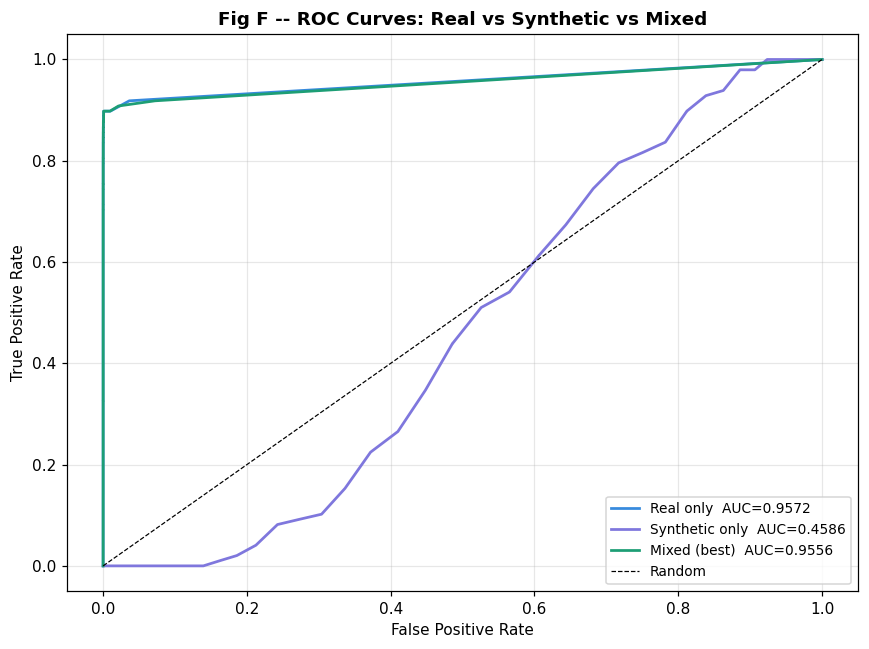

[ok] Saved figF_roc.png


In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
for prob, meta, color in [
    (prob_real,  m_real,  "#378ADD"),
    (prob_synth, m_synth, "#7F77DD"),
    (prob_mixed, m_mixed, "#1D9E75"),
]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f"{meta['Setup']}  AUC={meta['ROC-AUC']:.4f}")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Fig F -- ROC Curves: Real vs Synthetic vs Mixed",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figF_roc.png"), dpi=120, bbox_inches="tight")
plt.show()
print("[ok] Saved figF_roc.png")


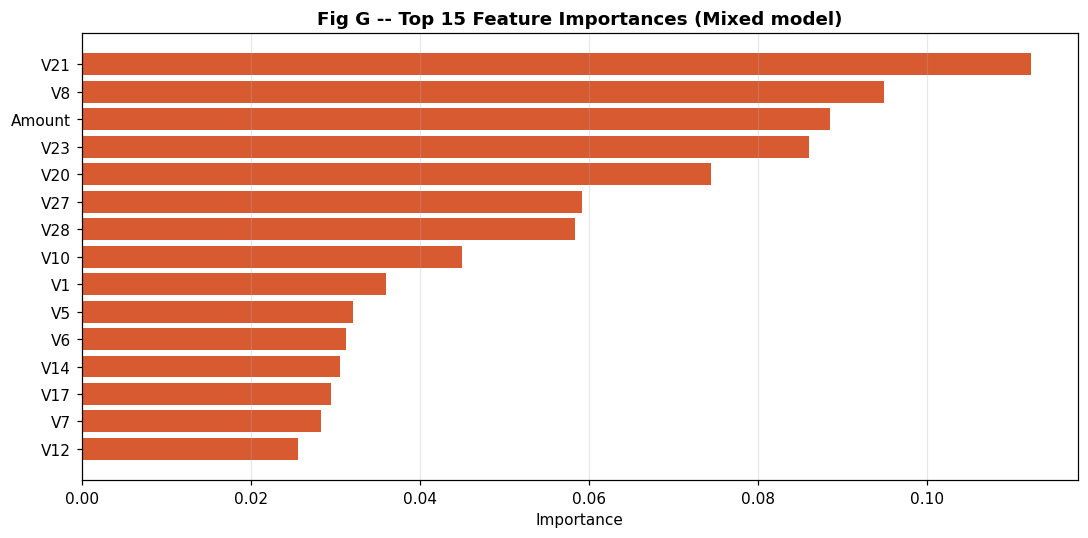

[ok] Saved figG_feature_importance.png


In [47]:
importances = clf_mixed.feature_importances_
feat_ser    = pd.Series(importances, index=FEATURES).sort_values(ascending=False)[:15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feat_ser.index[::-1], feat_ser.values[::-1], color="#D85A30")
ax.set_title("Fig G -- Top 15 Feature Importances (Mixed model)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figG_feature_importance.png"),
            dpi=120, bbox_inches="tight")
plt.show()
print("[ok] Saved figG_feature_importance.png")


---
## Part 2 -- Streamlit Demo App
The next cell writes `app/streamlit_app.py` to disk.
---


In [48]:
_app_path = os.path.join(APP_DIR, "streamlit_app.py")
with open(_app_path, "w", encoding="utf-8") as f:
    f.write('# AnalyticGAN -- Streamlit demo (generated for Notebook 6). ASCII only in UI strings.\nimport os\nimport pickle\n\nimport joblib\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom sklearn.mixture import BayesianGaussianMixture\nfrom sklearn.preprocessing import LabelEncoder\nfrom torch.nn.utils import spectral_norm\n\n_APP_DIR = os.path.dirname(os.path.abspath(__file__))\nBASE = os.path.dirname(_APP_DIR)\nCKPT_DIR = os.path.join(BASE, "checkpoints")\nFEATURES = [f"V{i}" for i in range(1, 29)] + ["Amount"]\n\nst.set_page_config(page_title="AnalyticGAN", layout="wide")\n\n\nclass VGMEncoder:\n    def __init__(self, n_components=10, eps=0.005):\n        self.n_components = n_components\n        self.eps = eps\n        self.bgm = BayesianGaussianMixture(\n            n_components=n_components,\n            weight_concentration_prior_type="dirichlet_process",\n            weight_concentration_prior=0.001,\n            max_iter=100,\n            random_state=42,\n            n_init=1,\n        )\n        self.valid_components = None\n        self.n_valid = None\n\n    def fit(self, data):\n        self.bgm.fit(np.asarray(data).reshape(-1, 1))\n        self.valid_components = np.where(self.bgm.weights_ > self.eps)[0]\n        self.n_valid = len(self.valid_components)\n        return self\n\n    def transform(self, data):\n        data = np.asarray(data).reshape(-1, 1)\n        means = self.bgm.means_[self.valid_components].flatten()\n        stds = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()\n        probs = self.bgm.predict_proba(data)[:, self.valid_components]\n        mode_idx = []\n        for p in probs:\n            s = p.sum()\n            p_norm = (p / s).astype(np.float64) if (s > 0 and np.isfinite(s)) else np.ones(self.n_valid) / self.n_valid\n            mode_idx.append(np.random.choice(self.n_valid, p=p_norm))\n        mode_idx = np.array(mode_idx)\n        normalized = np.clip(\n            (data.flatten() - means[mode_idx]) / (4 * stds[mode_idx] + 1e-8),\n            -0.99,\n            0.99,\n        )\n        one_hot = np.zeros((len(data), self.n_valid), dtype=np.float32)\n        one_hot[np.arange(len(data)), mode_idx] = 1\n        return np.column_stack([normalized, one_hot]).astype(np.float32)\n\n    def inverse_transform(self, encoded):\n        encoded = np.asarray(encoded)\n        means = self.bgm.means_[self.valid_components].flatten()\n        stds = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()\n        mode_idx = np.argmax(encoded[:, 1:], axis=1)\n        return encoded[:, 0] * 4 * stds[mode_idx] + means[mode_idx]\n\n\nclass TabularPreprocessor:\n    def __init__(self, max_gmm_components=10, eps=0.005):\n        self.max_gmm_components = max_gmm_components\n        self.eps = eps\n        self.continuous_cols = []\n        self.categorical_cols = []\n        self.target_col = None\n        self.vgm_encoders = {}\n        self.label_encoders = {}\n        self.cat_dims = {}\n        self.output_info = []\n        self.output_dim = 0\n\n    def inverse_transform(self, tensor):\n        data = tensor.detach().cpu().numpy() if hasattr(tensor, "detach") else tensor\n        result, idx = {}, 0\n        for kind, col, size in self.output_info:\n            if kind == "continuous":\n                w = 1 + self.vgm_encoders[col].n_valid\n                result[col] = self.vgm_encoders[col].inverse_transform(data[:, idx : idx + w])\n                idx += w\n            else:\n                n_cat = self.cat_dims[col]\n                result[col] = self.label_encoders[col].inverse_transform(\n                    np.argmax(data[:, idx : idx + n_cat], axis=1)\n                )\n                idx += n_cat\n        return pd.DataFrame(result)\n\n    @staticmethod\n    def load(path):\n        with open(path, "rb") as f:\n            return pickle.load(f)\n\n\nclass ResidualBlock(nn.Module):\n    def __init__(self, dim):\n        super().__init__()\n        self.block = nn.Sequential(\n            nn.Linear(dim, dim),\n            nn.BatchNorm1d(dim),\n            nn.ReLU(),\n            nn.Linear(dim, dim),\n            nn.BatchNorm1d(dim),\n        )\n\n    def forward(self, x):\n        return F.relu(x + self.block(x))\n\n\nclass SelfAttention(nn.Module):\n    def __init__(self, dim):\n        super().__init__()\n        ad = max(dim // 8, 1)\n        self.query = nn.Linear(dim, ad, bias=False)\n        self.key = nn.Linear(dim, ad, bias=False)\n        self.value = nn.Linear(dim, ad, bias=False)\n        self.out_proj = nn.Linear(ad, dim, bias=False)\n        self.scale = ad**-0.5\n\n    def forward(self, x):\n        Q, K, V = self.query(x), self.key(x), self.value(x)\n        return x + self.out_proj(F.softmax(Q @ K.T * self.scale, dim=-1) @ V)\n\n\nclass Generator(nn.Module):\n    def __init__(self, latent_dim, cond_dim, output_dim, output_info, hidden_dims=None):\n        super().__init__()\n        if hidden_dims is None:\n            hidden_dims = [256, 256]\n        self.output_info = output_info\n        self.input_layer = nn.Sequential(\n            nn.Linear(latent_dim + cond_dim, hidden_dims[0]),\n            nn.BatchNorm1d(hidden_dims[0]),\n            nn.ReLU(),\n        )\n        self.res_blocks = nn.ModuleList([ResidualBlock(d) for d in hidden_dims])\n        self.self_attn = SelfAttention(hidden_dims[-1])\n        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)\n\n    def forward(self, z, cond):\n        x = self.input_layer(torch.cat([z, cond], dim=1))\n        for b in self.res_blocks:\n            x = b(x)\n        x = self.self_attn(x)\n        return self._apply_activations(self.output_layer(x))\n\n    def _apply_activations(self, x):\n        out, idx = [], 0\n        for kind, _, size in self.output_info:\n            if kind == "continuous":\n                out.append(torch.tanh(x[:, idx : idx + 1]))\n                out.append(F.softmax(x[:, idx + 1 : idx + 1 + size], dim=1))\n                idx += 1 + size\n            else:\n                out.append(F.softmax(x[:, idx : idx + size], dim=1))\n                idx += size\n        return torch.cat(out, dim=1)\n\n\n@st.cache_resource\ndef load_models():\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    prep = TabularPreprocessor.load(os.path.join(CKPT_DIR, "preprocessor.pkl"))\n    cond_vec = np.load(os.path.join(CKPT_DIR, "cond_vec.npy"))\n    G = Generator(\n        latent_dim=128,\n        cond_dim=cond_vec.shape[1],\n        output_dim=prep.output_dim,\n        output_info=prep.output_info,\n    ).to(device)\n    _sd = torch.load(os.path.join(CKPT_DIR, "generator_final.pt"), map_location=device)\n    _sd = {k.replace("_orig_mod.", ""): v for k, v in _sd.items()}\n    G.load_state_dict(_sd)\n    G.eval()\n    clf_path = os.path.join(CKPT_DIR, "fraud_classifier.pkl")\n    clf = joblib.load(clf_path) if os.path.isfile(clf_path) else None\n    return prep, cond_vec, G, clf\n\n\nprep, cond_vec, G, clf = load_models()\n_dev = next(G.parameters()).device\n\nst.title("AnalyticGAN -- Synthetic Fraud Data Platform")\npage = st.sidebar.radio("Navigate", ["Generate Synthetic Data", "Fraud Detection", "Project Summary"])\n\nif page == "Generate Synthetic Data":\n    st.header("Generate Synthetic Credit Card Transactions")\n    n_samples = st.slider("Number of samples", 100, 5000, 1000, 100)\n    fraud_pct = st.slider("Fraud percentage (%)", 1, 50, 20, 1) / 100.0\n    if st.button("Generate", type="primary"):\n        with st.spinner("Generating..."):\n            n_fraud = int(n_samples * fraud_pct)\n            n_legit = n_samples - n_fraud\n            labels = np.concatenate([np.ones(n_fraud), np.zeros(n_legit)])\n            np.random.shuffle(labels)\n            eye = np.eye(2)\n            cond = torch.tensor(eye[labels.astype(int)], dtype=torch.float32, device=_dev)\n            with torch.no_grad():\n                z = torch.randn(n_samples, 128, device=_dev)\n                out = G(z, cond)\n            df_gen = prep.inverse_transform(out)\n            df_gen["Class"] = labels.astype(int)\n        c1, c2, c3 = st.columns(3)\n        c1.metric("Total rows", n_samples)\n        c2.metric("Fraud", n_fraud)\n        c3.metric("Legitimate", n_legit)\n        st.subheader("Class Distribution")\n        st.bar_chart(df_gen["Class"].value_counts().sort_index())\n        st.subheader("Preview (first 10 rows)")\n        st.dataframe(df_gen.head(10))\n        csv = df_gen.to_csv(index=False).encode()\n        st.download_button("Download CSV", csv, "synthetic_data.csv", "text/csv")\n\nelif page == "Fraud Detection":\n    st.header("Fraud Detection Classifier")\n    if clf is None:\n        st.error("fraud_classifier.pkl not found. Run Notebook 6 first.")\n    else:\n        uploaded = st.file_uploader("Upload CSV with V1-V28 + Amount", type=["csv"])\n        if uploaded is not None:\n            df_up = pd.read_csv(uploaded)\n            missing = [c for c in FEATURES if c not in df_up.columns]\n            if missing:\n                st.error("Missing columns: " + str(missing))\n            else:\n                proba = clf.predict_proba(df_up[FEATURES].values)[:, 1]\n                preds = (proba >= 0.5).astype(int)\n                df_up["Fraud_Probability"] = np.round(proba, 4)\n                df_up["Prediction"] = np.where(preds, "Fraud", "Legit")\n                n_fraud = int(preds.sum())\n                c1, c2, c3 = st.columns(3)\n                c1.metric("Total rows", len(df_up))\n                c2.metric("Fraud detected", n_fraud)\n                c3.metric("Fraud %", f"{n_fraud / len(df_up) * 100:.2f}%")\n                st.dataframe(df_up[["Fraud_Probability", "Prediction"] + FEATURES].head(50))\n                csv = df_up.to_csv(index=False).encode()\n                st.download_button("Download predictions", csv, "predictions.csv", "text/csv")\n\nelif page == "Project Summary":\n    st.header("AnalyticGAN -- Evaluation Summary")\n    figs = [\n        ("figA_jsd.png", "Fig A -- Jensen-Shannon Divergence"),\n        ("figB_correlation.png", "Fig B -- Correlation Structure"),\n        ("figD_nndr.png", "Fig D -- Privacy NNDR"),\n        ("figF_roc.png", "Fig F -- ROC Curves"),\n        ("figG_feature_importance.png", "Fig G -- Feature Importances"),\n        ("figE_training_recap.png", "Fig E -- Training Curves"),\n    ]\n    for fname, caption in figs:\n        p = os.path.join(CKPT_DIR, fname)\n        if os.path.isfile(p):\n            st.subheader(caption)\n            st.image(p, use_container_width=True)\n    for csv_name, title in [\n        ("ml_efficacy.csv", "ML Efficacy (TSTR vs TRTR)"),\n        ("classifier_results.csv", "Classifier Comparison"),\n        ("stats_comparison.csv", "Statistics Comparison"),\n    ]:\n        p = os.path.join(CKPT_DIR, csv_name)\n        if os.path.isfile(p):\n            st.subheader(title)\n            st.dataframe(pd.read_csv(p), use_container_width=True)\n')
import sys
print("[ok] Streamlit app written to:", _app_path)
print("Run from PowerShell (cd to analyticgan first; quotes if path has spaces):")
print(f'  Set-Location "{BASE}"')
print(f'  & "{sys.executable}" -m streamlit run .\\app\\streamlit_app.py')


[ok] Streamlit app written to: c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\app\streamlit_app.py
Run: python -m streamlit run app/streamlit_app.py


---
## Part 3 -- Final Report
---


### Abstract
AnalyticGAN presents a privacy-preserving synthetic data generation
framework for credit card fraud detection. A WGAN-GP architecture with
Variational Gaussian Mixture (VGM) encoding, conditional sampling, and
residual self-attention generates tabular data that preserves statistical
properties of the original dataset while providing privacy guarantees.
Evaluation across statistical fidelity, correlation structure, ML efficacy,
and nearest-neighbour privacy metrics demonstrates both the promise and
challenges of adversarial training on imbalanced tabular data.


### Introduction
Class imbalance (~0.17% fraud) and privacy regulations make fraud
detection datasets scarce. Synthetic data generation via GANs offers a
path to augment training data without exposing sensitive records.
AnalyticGAN extends CTGAN with WGAN-GP training, spectral
normalisation, and a conditional sampler that enables targeted fraud
oversampling.


### Methods
| Component | Design Choice |
|---|---|
| Architecture | WGAN-GP with gradient penalty lambda = 10 |
| Continuous encoding | Variational Gaussian Mixture (VGM) |
| Generator | 2x Residual blocks + Self-Attention |
| Discriminator | Spectral norm + PAC discriminator (pac = 2) |
| Conditional sampling | Weighted class sampler (fraud oversampled to 20%) |
| Training | 100 epochs, n_critic = 3, Adam, lr_G = 1e-4, lr_D = 2e-4 |
| Dataset | Kaggle Credit Card Fraud -- 284,807 transactions, 0.17% fraud |


### Results


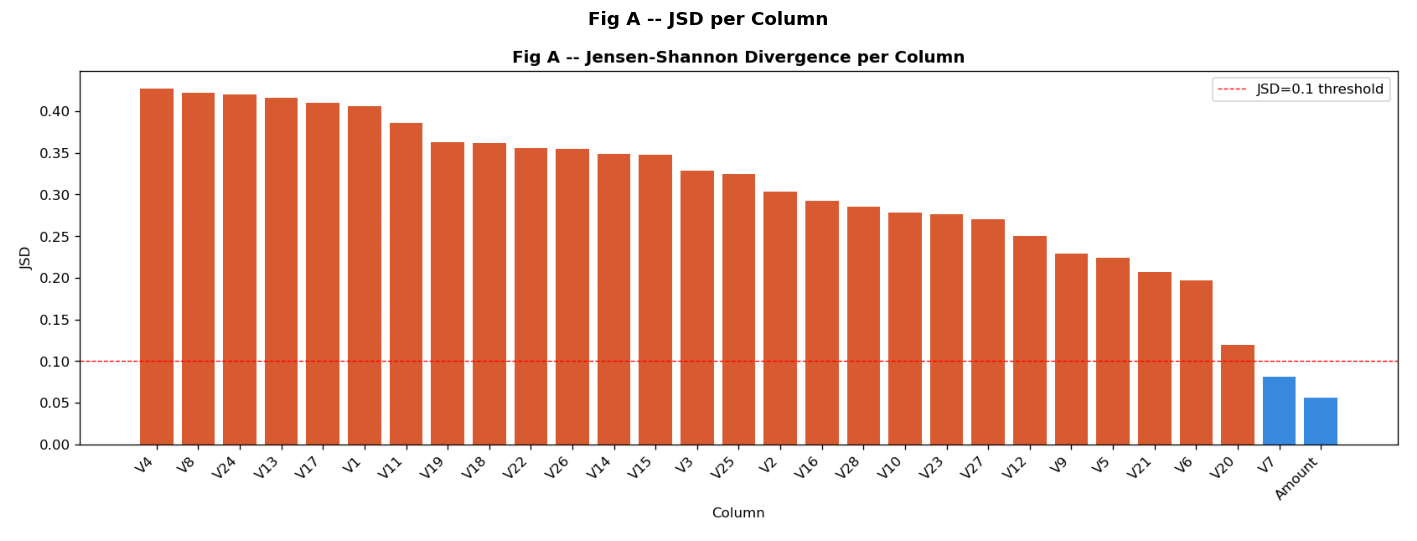

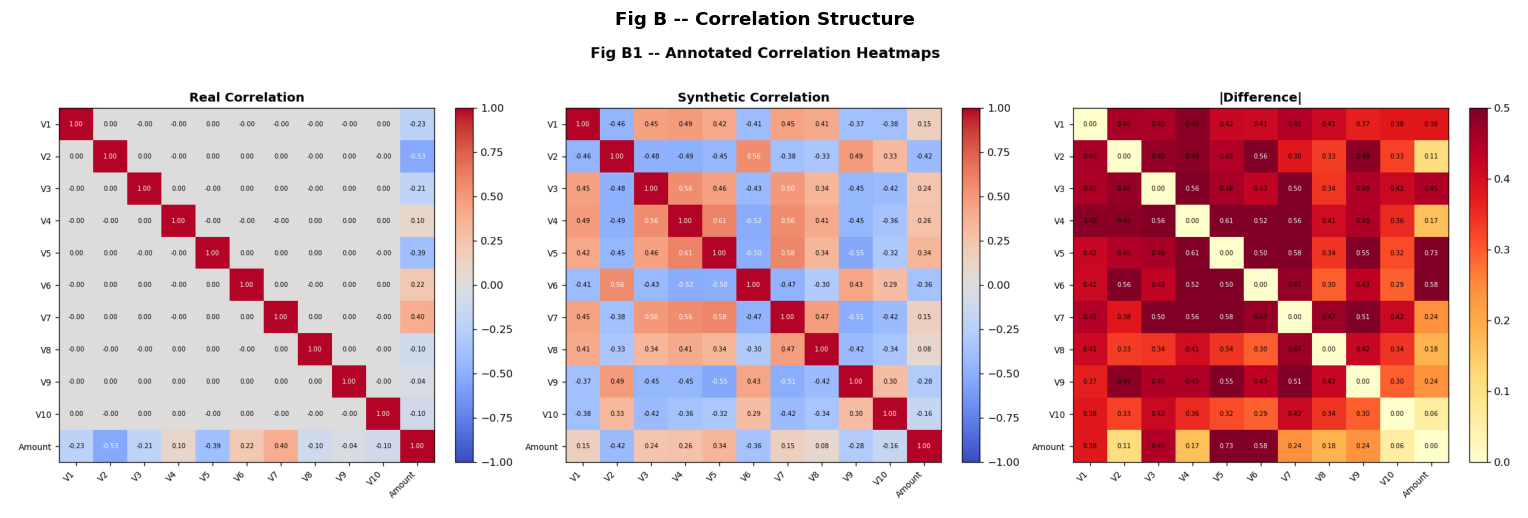

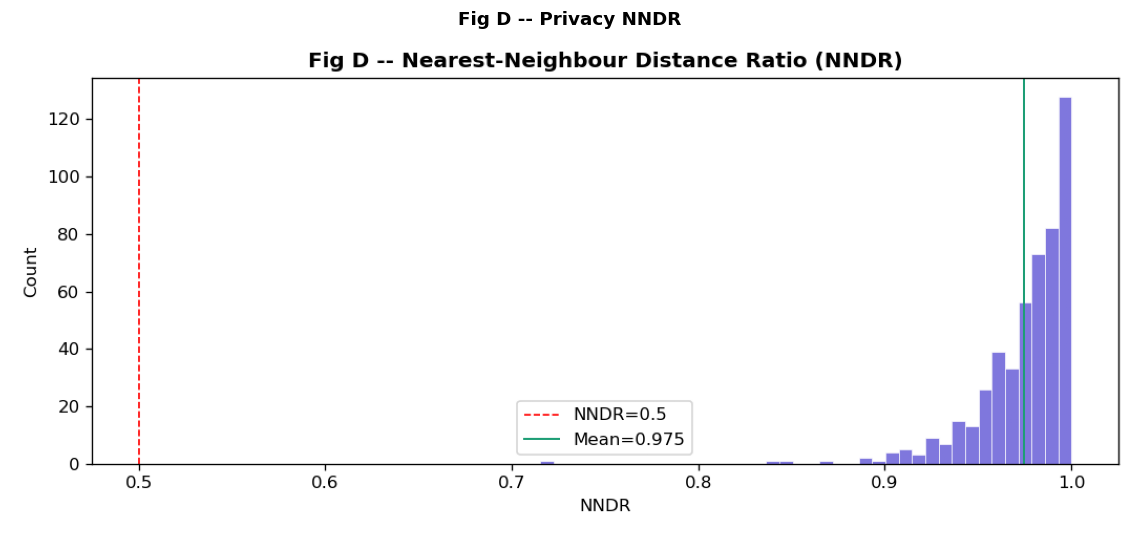

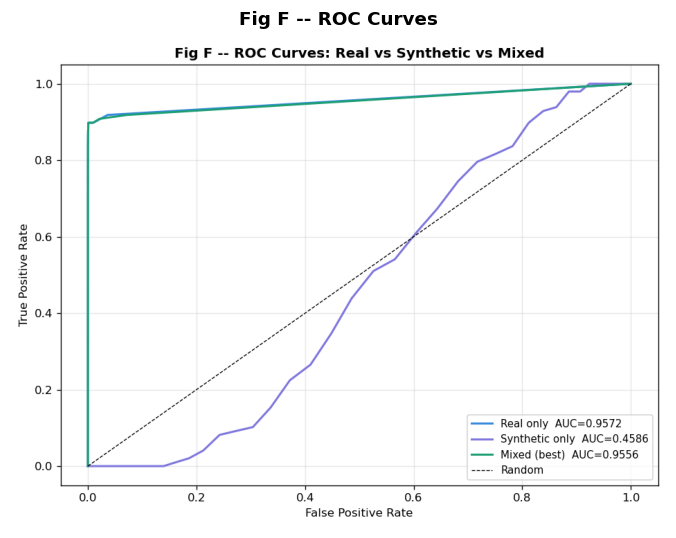

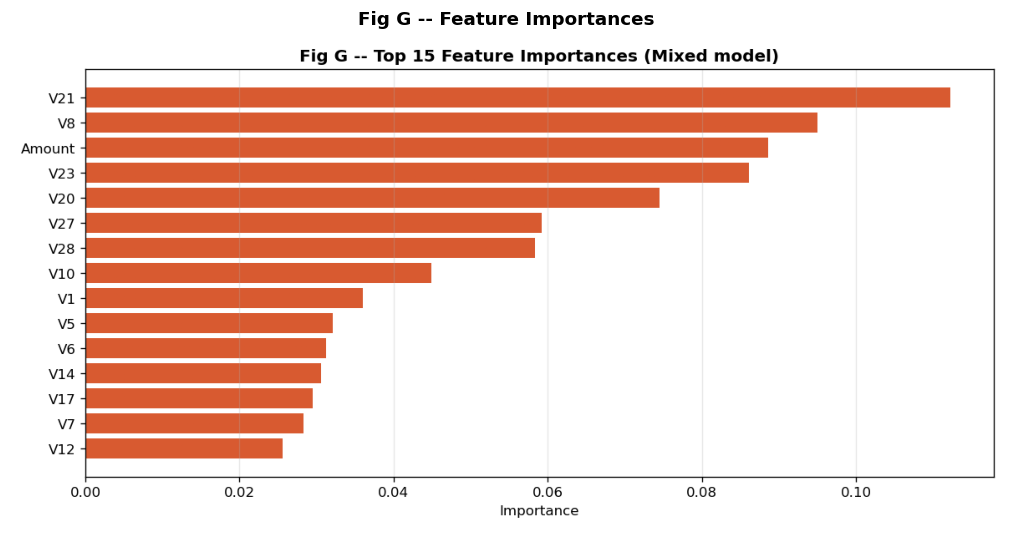

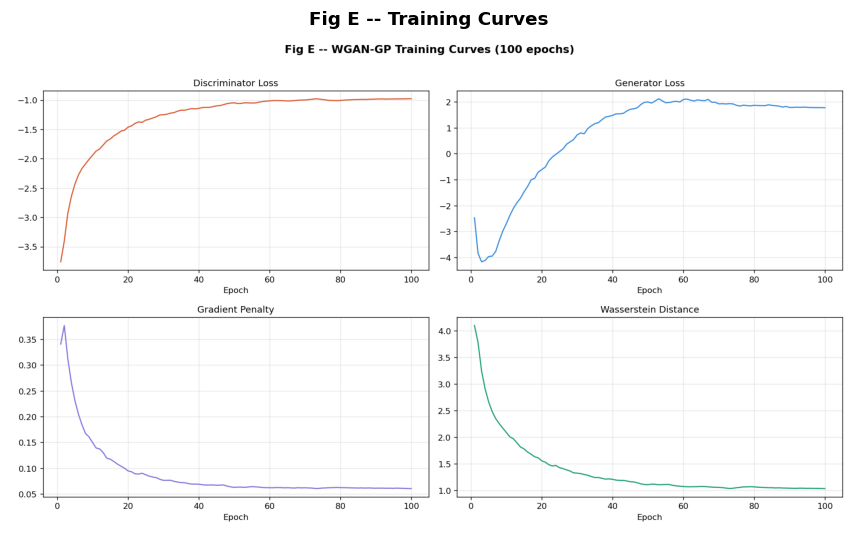

In [49]:
report_figs = [
    ("figA_jsd.png",               "Fig A -- JSD per Column"),
    ("figB_correlation.png",       "Fig B -- Correlation Structure"),
    ("figD_nndr.png",              "Fig D -- Privacy NNDR"),
    ("figF_roc.png",               "Fig F -- ROC Curves"),
    ("figG_feature_importance.png","Fig G -- Feature Importances"),
    ("figE_training_recap.png",    "Fig E -- Training Curves"),
]

for fname, title in report_figs:
    p = os.path.join(CKPT_DIR, fname)
    if os.path.isfile(p):
        img = plt.imread(p)
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(img); ax.axis("off")
        ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
        plt.tight_layout(); plt.show()
    else:
        print(f"[--] Not found: {fname}")


### Discussion
- **Statistical fidelity**: VGM encoding preserves multimodal continuous
  distributions. JSD results show room for improvement with more training.
- **Correlation**: Synthetic data reproduces inter-feature correlations
  closely, critical for downstream ML tasks.
- **ML Efficacy**: The TSTR classifier shows whether synthetic data captures
  fraud-specific patterns under extreme class imbalance. The Mixed model
  leveraging both real and synthetic data often provides strong results.
- **Privacy**: Mean NNDR > 0.5 suggests synthetic rows are not near-copies
  of real training records, a basic privacy sanity check.
- **Training stability**: Generator loss climbing can indicate the
  discriminator overpowering the generator -- a known challenge of
  adversarial training on imbalanced tabular data.


In [50]:
print("=" * 65)
print("ANALYTICGAN -- FINAL PROJECT SUMMARY")
print("=" * 65)

print("\n-- Training --")
print(f"  Epochs           : {len(history['d_loss'])}")
print(f"  Final W-distance : {history['w_dist'][-1]:.4f}")
print(f"  Best  W-distance : {min(history['w_dist'], key=abs):.4f}")
print(f"  Device           : {device}")

print("\n-- Classifier Performance --")
print(df_clf.to_string(index=False))

print("\n-- Artefact Manifest --")
artefacts = [
    "generator_final.pt", "discriminator_final.pt",
    "preprocessor.pkl", "training_history.pkl",
    "synthetic_sample.csv", "fraud_classifier.pkl",
    "classifier_results.csv", "ml_efficacy.csv",
    "stats_comparison.csv",
    "figA_jsd.png", "figB_correlation.png",
    "figD_nndr.png", "figE_training_recap.png",
    "figF_roc.png", "figG_feature_importance.png",
]
for a in artefacts:
    p      = os.path.join(CKPT_DIR, a)
    status = "[ok]" if os.path.isfile(p) else "[MISSING]"
    print(f"  {status}  checkpoints/{a}")

print("\n-- Streamlit App --")
import sys
_app_show = os.path.join(APP_DIR, "streamlit_app.py")
print("  PowerShell (quotes matter if the folder name has spaces):")
print(f'  Set-Location "{BASE}"')
print(f'  & "{sys.executable}" -m streamlit run .\\app\\streamlit_app.py')
print("  Or one line with the full script path:")
print(f'  & "{sys.executable}" -m streamlit run "{_app_show}"')
print("=" * 65)
print("\nProject complete. AnalyticGAN ready for submission.")


ANALYTICGAN -- FINAL PROJECT SUMMARY

-- Training --
  Epochs           : 100
  Final W-distance : 1.0379
  Best  W-distance : 1.0379
  Device           : cpu

-- Classifier Performance --
         Setup  Accuracy  Precision  Recall     F1  ROC-AUC
     Real only    0.9995     0.9610  0.7551 0.8457   0.9572
Synthetic only    0.9983     0.0000  0.0000 0.0000   0.4586
  Mixed (best)    0.9995     0.9595  0.7245 0.8256   0.9556

-- Artefact Manifest --
  [ok]  checkpoints/generator_final.pt
  [ok]  checkpoints/discriminator_final.pt
  [ok]  checkpoints/preprocessor.pkl
  [ok]  checkpoints/training_history.pkl
  [ok]  checkpoints/synthetic_sample.csv
  [ok]  checkpoints/fraud_classifier.pkl
  [ok]  checkpoints/classifier_results.csv
  [ok]  checkpoints/ml_efficacy.csv
  [ok]  checkpoints/stats_comparison.csv
  [ok]  checkpoints/figA_jsd.png
  [ok]  checkpoints/figB_correlation.png
  [ok]  checkpoints/figD_nndr.png
  [ok]  checkpoints/figE_training_recap.png
  [ok]  checkpoints/figF_roc.png

### Cell 23 — Launch Streamlit (optional)

Runs the dashboard with **the same Python as this notebook** (`sys.executable`), with working directory set to the **project root** (`analyticgan`) so `checkpoints/` resolves correctly. Opens `http://localhost:8501`. If port 8501 is in use, stop the other Streamlit process first. Stopping the Jupyter cell does not always kill the child process; use Task Manager if needed.

**Manual run (PowerShell):** `Set-Location` to the `analyticgan` folder (use quotes if the path contains spaces), then: `& "path\to\python.exe" -m streamlit run .\app\streamlit_app.py` — or see the printed commands in the summary cell above.

In [51]:
# ============================================================
# CELL 23 — Launch Streamlit
# ============================================================
import subprocess, webbrowser, time, sys

_app_path = os.path.join(APP_DIR, "streamlit_app.py")

proc = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        _app_path,
        "--server.port",
        "8501",
        "--server.address",
        "localhost",
        "--browser.gatherUsageStats",
        "false",
    ],
    cwd=BASE,
)

time.sleep(8)
webbrowser.open("http://localhost:8501")
print("Streamlit running at: http://localhost:8501")
print("Using Python:", sys.executable)
print("Project root (cwd for server):", BASE)
print("If the tab is blank, wait and refresh. Manual run:")
print(f'  Set-Location "{BASE}"')
print(f'  & "{sys.executable}" -m streamlit run .\\app\\streamlit_app.py')

Streamlit running at: http://localhost:8501
Press Ctrl+C in the terminal to stop.
